In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path("../results")

In [10]:
result_files = [
    "mfcc_mlp_baseline_results.csv",
    "logmel_cnn_lr1e3_results.csv",
    "logmel_cnn_lr1e4_dropout50_results.csv",
    "logmel_cnn_lr1e4_dropout30_results.csv",
    "logmel_cnn_deeper_lr1e4_dropout50_results.csv"
]

dfs = []

for file in result_files:
    path = RESULTS_DIR / file

    if path.exists():
        df_temp = pd.read_csv(path)
        df_temp["source_file"] = file
        dfs.append(df_temp)
        print(f"Loaded: {file}")
    else:
        print(f"Missing: {file}")

results_df = pd.concat(dfs, ignore_index=True)
results_df

Loaded: mfcc_mlp_baseline_results.csv
Loaded: logmel_cnn_lr1e3_results.csv
Loaded: logmel_cnn_lr1e4_dropout50_results.csv
Loaded: logmel_cnn_lr1e4_dropout30_results.csv
Loaded: logmel_cnn_deeper_lr1e4_dropout50_results.csv


,model,features,validation_accuracy,validation_macro_f1,test_accuracy,test_macro_f1,hidden_layers,learning_rate,batch_size,source_file,experiment,architecture,dropout_dense,notes
0,MFCC + MLP,40 MFCC mean + std,0.890710,0.886493,0.918033,0.910807,"(128, 64)",0.0010,32,mfcc_mlp_baseline_results.csv,NaN,NaN,NaN,NaN
1,Log-mel + CNN,64-bin log-mel spectrogram,0.213115,0.131206,0.191257,0.110859,NaN,0.0010,32,logmel_cnn_lr1e3_results.csv,initial_lr1e-3,Conv32-Conv64-Conv128-GAP-Dense128,0.3,High learning rate; overfitting observed
2,Log-mel CNN lr=1e-4 dropout=0.50,64-bin log-mel spectrogram,0.923497,0.922711,0.928962,0.927094,NaN,0.0001,32,logmel_cnn_lr1e4_dropout50_results.csv,lr1e-4_dropout50,Conv32-Conv64-Conv128-GAP-Dense128,0.5,Lower learning rate and stronger dropout impro...
3,Log-mel CNN lr=1e-4 dropout=0.30,64-bin log-mel spectrogram,0.939891,0.939927,0.928962,0.926263,NaN,0.0001,32,logmel_cnn_lr1e4_dropout30_results.csv,lr1e-4_dropout30,Conv32-Conv64-Conv128-GAP-Dense128,0.3,Tests effect of weaker dropout regularization
4,Deeper Log-mel CNN lr=1e-4 dropout=0.50,64-bin log-mel spectrogram,0.939891,0.938751,0.928962,0.929282,NaN,0.0001,32,logmel_cnn_deeper_lr1e4_dropout50_results.csv,deeper_lr1e-4_dropout50,Conv32-Conv64-Conv128-Conv256-GAP-Dense128,0.5,Tests effect of adding a fourth convolutional ...


In [3]:
clean_results = results_df[
    [
        "model",
        "validation_accuracy",
        "validation_macro_f1",
        "test_accuracy",
        "test_macro_f1",
        "learning_rate",
        "batch_size",
        "dropout_dense",
        "architecture"
    ]
].copy()



clean_results

clean_results_rounded = clean_results.copy()

for col in ["validation_accuracy", "validation_macro_f1", "test_accuracy", "test_macro_f1"]:
    clean_results_rounded[col] = clean_results_rounded[col].round(4)

clean_results_rounded

,model,validation_accuracy,validation_macro_f1,test_accuracy,test_macro_f1,learning_rate,batch_size,dropout_dense,architecture
0,MFCC + MLP,0.8907,0.8865,0.9180,0.9108,0.0010,32,NaN,NaN
1,Log-mel + CNN,0.2131,0.1312,0.1913,0.1109,0.0010,32,0.3,Conv32-Conv64-Conv128-GAP-Dense128
2,Log-mel CNN lr=1e-4 dropout=0.50,0.9235,0.9227,0.9290,0.9271,0.0001,32,0.5,Conv32-Conv64-Conv128-GAP-Dense128
3,Log-mel CNN lr=1e-4 dropout=0.30,0.9399,0.9399,0.9290,0.9263,0.0001,32,0.3,Conv32-Conv64-Conv128-GAP-Dense128
4,Deeper Log-mel CNN lr=1e-4 dropout=0.50,0.9399,0.9388,0.9290,0.9293,0.0001,32,0.5,Conv32-Conv64-Conv128-Conv256-GAP-Dense128


In [4]:
clean_results_rounded.to_csv(
    RESULTS_DIR / "final_model_comparison.csv",
    index=False
)

print("Saved final comparison table.")

Saved final comparison table.


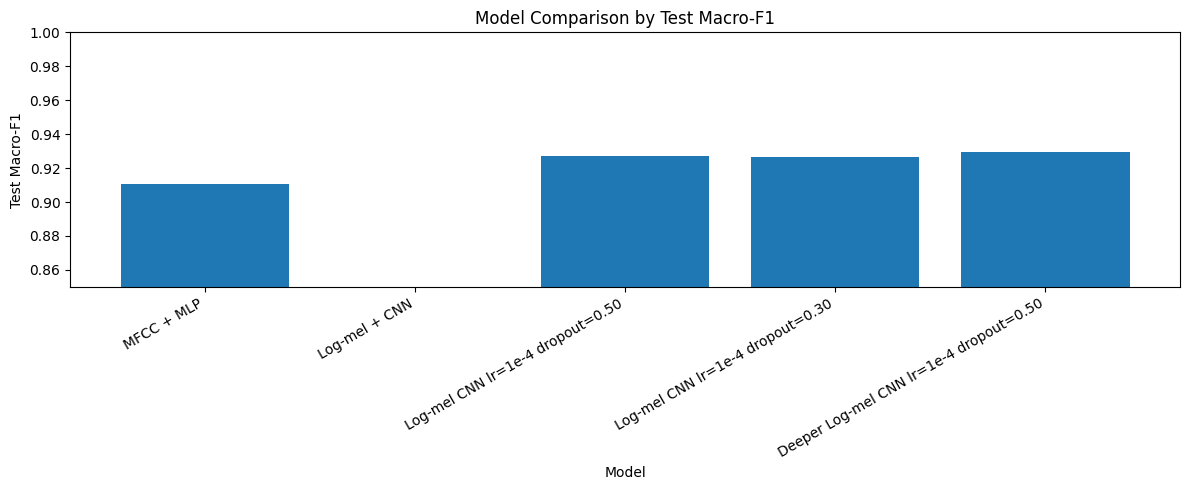

In [5]:
plt.figure(figsize=(12, 5))

plt.bar(clean_results_rounded["model"], clean_results_rounded["test_macro_f1"])

plt.title("Model Comparison by Test Macro-F1")
plt.xlabel("Model")
plt.ylabel("Test Macro-F1")
plt.ylim(0.85, 1.0)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

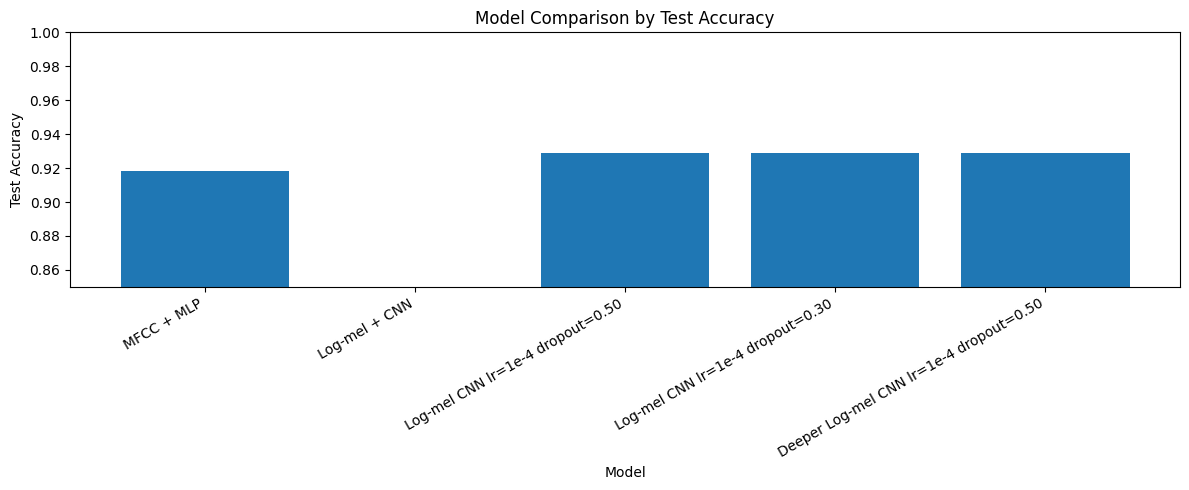

In [6]:
plt.figure(figsize=(12, 5))

plt.bar(clean_results_rounded["model"], clean_results_rounded["test_accuracy"])

plt.title("Model Comparison by Test Accuracy")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.ylim(0.85, 1.0)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [7]:
clean_results_rounded.sort_values("test_macro_f1", ascending=False)

,model,validation_accuracy,validation_macro_f1,test_accuracy,test_macro_f1,learning_rate,batch_size,dropout_dense,architecture
4,Deeper Log-mel CNN lr=1e-4 dropout=0.50,0.9399,0.9388,0.9290,0.9293,0.0001,32,0.5,Conv32-Conv64-Conv128-Conv256-GAP-Dense128
2,Log-mel CNN lr=1e-4 dropout=0.50,0.9235,0.9227,0.9290,0.9271,0.0001,32,0.5,Conv32-Conv64-Conv128-GAP-Dense128
3,Log-mel CNN lr=1e-4 dropout=0.30,0.9399,0.9399,0.9290,0.9263,0.0001,32,0.3,Conv32-Conv64-Conv128-GAP-Dense128
0,MFCC + MLP,0.8907,0.8865,0.9180,0.9108,0.0010,32,NaN,NaN
1,Log-mel + CNN,0.2131,0.1312,0.1913,0.1109,0.0010,32,0.3,Conv32-Conv64-Conv128-GAP-Dense128


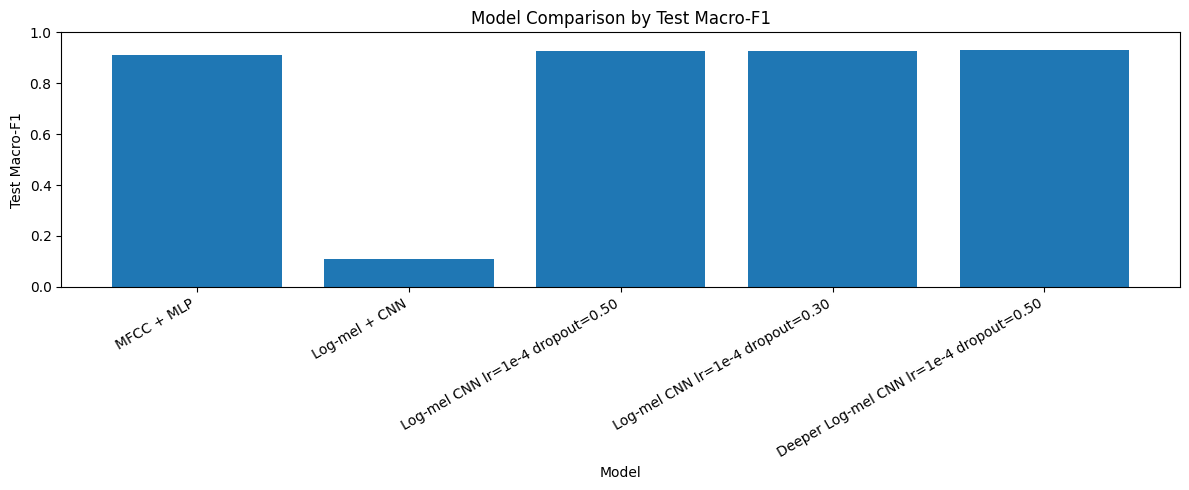

In [8]:
plt.figure(figsize=(12, 5))
plt.bar(clean_results_rounded["model"], clean_results_rounded["test_macro_f1"])
plt.title("Model Comparison by Test Macro-F1")
plt.xlabel("Model")
plt.ylabel("Test Macro-F1")
plt.ylim(0, 1)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

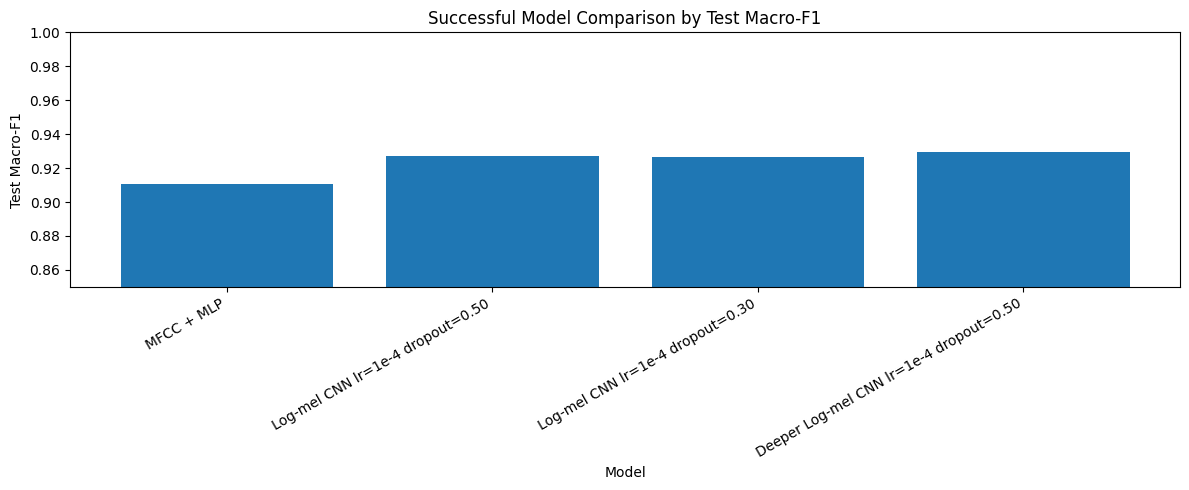

In [11]:
successful_results = clean_results_rounded[
    clean_results_rounded["test_macro_f1"] > 0.5
]

plt.figure(figsize=(12, 5))
plt.bar(successful_results["model"], successful_results["test_macro_f1"])
plt.title("Successful Model Comparison by Test Macro-F1")
plt.xlabel("Model")
plt.ylabel("Test Macro-F1")
plt.ylim(0.85, 1.0)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [12]:
FIGURES_DIR = Path("../figures")
FIGURES_DIR.mkdir(exist_ok=True)

plt.savefig(FIGURES_DIR / "model_comparison_all_test_macro_f1.png", dpi=300, bbox_inches="tight")

plt.savefig(FIGURES_DIR / "model_comparison_successful_test_macro_f1.png", dpi=300, bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [13]:
report_table = clean_results_rounded[
    [
        "model",
        "validation_macro_f1",
        "test_accuracy",
        "test_macro_f1",
        "learning_rate",
        "dropout_dense",
        "architecture"
    ]
].copy()

report_table = report_table.sort_values("test_macro_f1", ascending=False)

report_table.to_csv(RESULTS_DIR / "report_ready_results_table.csv", index=False)

report_table

,model,validation_macro_f1,test_accuracy,test_macro_f1,learning_rate,dropout_dense,architecture
4,Deeper Log-mel CNN lr=1e-4 dropout=0.50,0.9388,0.9290,0.9293,0.0001,0.5,Conv32-Conv64-Conv128-Conv256-GAP-Dense128
2,Log-mel CNN lr=1e-4 dropout=0.50,0.9227,0.9290,0.9271,0.0001,0.5,Conv32-Conv64-Conv128-GAP-Dense128
3,Log-mel CNN lr=1e-4 dropout=0.30,0.9399,0.9290,0.9263,0.0001,0.3,Conv32-Conv64-Conv128-GAP-Dense128
0,MFCC + MLP,0.8865,0.9180,0.9108,0.0010,NaN,NaN
1,Log-mel + CNN,0.1312,0.1913,0.1109,0.0010,0.3,Conv32-Conv64-Conv128-GAP-Dense128
